In [ ]:
"""
MangoCare - Mango Fruit Disease Detection - MODEL A: EfficientNetB0
========================================================================
Pipeline: dedup (threshold-based) -> stratified 70/15/15 split ->
3-stage progressive fine-tuning -> TTA evaluation -> full reports.

pip install tensorflow scikit-learn imagehash pillow matplotlib seaborn --quiet
"""

import os
import json
import numpy as np
import tensorflow as tf
from PIL import Image
import imagehash
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau




Classes found (5): ['Alternaria', 'Anthracnose', 'Black Mould Rot', 'Healthy', 'Stem end Rot']
Total images before dedup: 5000


In [ ]:
DATASET_DIR = r"D:\Fruit Disease detection\Mango Fruit Dataset"  
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123
OUT_DIR = "mango_fruit_model_efficientnetb0"
os.makedirs(OUT_DIR, exist_ok=True)

NEAR_DUP_THRESHOLD = 5
STAGE1_EPOCHS = 20
STAGE2_EPOCHS = 15
STAGE3_EPOCHS = 10


class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
NUM_CLASSES = len(class_names)
print(f"Classes found ({NUM_CLASSES}): {class_names}")

filepaths, labels = [], []
for idx, cls in enumerate(class_names):
    cls_dir = os.path.join(DATASET_DIR, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            filepaths.append(os.path.join(cls_dir, fname))
            labels.append(idx)
print(f"Total images before dedup: {len(filepaths)}")

In [ ]:

print("Removing near-duplicates (threshold-based hash distance)...")
keep_mask = [True] * len(filepaths)
by_class = defaultdict(list)
for i, (fp, lb) in enumerate(zip(filepaths, labels)):
    by_class[lb].append(i)

removed = 0
for lb, indices in by_class.items():
    hashes = []
    for i in indices:
        try:
            h = imagehash.phash(Image.open(filepaths[i]))
            hashes.append((i, h))
        except Exception:
            keep_mask[i] = False
            continue
    used = set()
    for a in range(len(hashes)):
        i_a, h_a = hashes[a]
        if i_a in used or not keep_mask[i_a]:
            continue
        for b in range(a + 1, len(hashes)):
            i_b, h_b = hashes[b]
            if i_b in used:
                continue
            if h_a - h_b <= NEAR_DUP_THRESHOLD:
                keep_mask[i_b] = False
                used.add(i_b)
                removed += 1

filepaths = [fp for fp, keep in zip(filepaths, keep_mask) if keep]
labels = [lb for lb, keep in zip(labels, keep_mask) if keep]
print(f"Removed {removed} near-duplicate images. Remaining: {len(filepaths)}")

Removing near-duplicates (threshold-based hash distance)...
Removed 51 near-duplicate images. Remaining: 4949


In [ ]:

train_fp, temp_fp, train_lb, temp_lb = train_test_split(
    filepaths, labels, test_size=0.30, stratify=labels, random_state=SEED
)
val_fp, test_fp, val_lb, test_lb = train_test_split(
    temp_fp, temp_lb, test_size=0.50, stratify=temp_lb, random_state=SEED
)
print(f"Train: {len(train_fp)}  Val: {len(val_fp)}  Test: {len(test_fp)}")

Train: 3464  Val: 742  Test: 743


In [ ]:

def make_dataset(filepaths, labels, training=False):
    path_ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        return img, label
    ds = path_ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
    return ds

train_dataset = make_dataset(train_fp, train_lb, training=True)
val_dataset = make_dataset(val_fp, val_lb)
test_dataset = make_dataset(test_fp, test_lb)


In [ ]:

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_lb), y=train_lb
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)



Class weights: {0: np.float64(0.9954022988505747), 1: np.float64(0.9954022988505747), 2: np.float64(1.0026049204052099), 3: np.float64(1.0084425036390101), 4: np.float64(0.9982708933717579)}


In [ ]:

data_augmentation = tf.keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    layers.RandomFlip("horizontal_and_vertical"),  # fruit can appear at any rotation
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
], name="augmentation")





In [ ]:
base_model = EfficientNetB0(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

def compile_model(lr):
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,168 (16.85 MB)

 Trainable params: 364,037 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
compile_model(1e-3)
stage1_cb = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(os.path.join(OUT_DIR, "stage1_best.keras"), monitor="val_accuracy", save_best_only=True),
]
print("\n=== STAGE 1: training head, backbone frozen ===")
history1 = model.fit(train_dataset, validation_data=val_dataset, epochs=STAGE1_EPOCHS,
                      class_weight=class_weight_dict, callbacks=stage1_cb)
print(history1.history.keys())
print("Final Training Accuracy :", history1.history["accuracy"][-1])
print("Final Validation Accuracy :", history1.history["val_accuracy"][-1])
print("Final Training Loss :", history1.history["loss"][-1])
print("Final Validation :", history1.history["val_loss"][-1])


=== STAGE 1: training head, backbone frozen ===
Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 90s 747ms/step - accuracy: 0.6764 - loss: 0.9586 - val_accuracy: 0.8221 - val_loss: 0.6624 - learning_rate: 0.0010
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 82s 756ms/step - accuracy: 0.7872 - loss: 0.6411 - val_accuracy: 0.8437 - val_loss: 0.5144 - learning_rate: 0.0010
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 80s 737ms/step - accuracy: 0.8103 - loss: 0.5682 - val_accuracy: 0.8666 - val_loss: 0.4441 - learning_rate: 0.0010
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 82s 749ms/step - accuracy: 0.8430 - loss: 0.4951 - val_accuracy: 0.8774 - val_loss: 0.3921 - learning_rate: 0.0010
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 83s 765ms/step - accuracy: 0.8479 - loss: 0.4700 - val_accuracy: 0.8868 - val_loss: 0.3549 - learning_rate: 0.0010
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 79s 722ms/step - accuracy: 0.8510 - loss: 0.4485 - val_accuracy: 0.8827 - val_loss: 0.3657 - learning_rate: 0.0010
Epoch 7/20
109/109 ━━

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
compile_model(1e-4)
stage2_cb = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(OUT_DIR, "stage2_best.keras"), monitor="val_accuracy", save_best_only=True),
]
print("\n=== STAGE 2: fine-tuning last 30 layers ===")
history2 = model.fit(train_dataset, validation_data=val_dataset, epochs=STAGE2_EPOCHS,
                      class_weight=class_weight_dict, callbacks=stage2_cb)
print(history2.history.keys())
print("Final Training Accuracy :", history2.history["accuracy"][-1])
print("Final Validation Accuracy :", history2.history["val_accuracy"][-1])
print("Final Training Loss :", history2.history["loss"][-1])
print("Final Validation :", history2.history["val_loss"][-1])



=== STAGE 2: fine-tuning last 30 layers ===
Epoch 1/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 112s 904ms/step - accuracy: 0.8689 - loss: 0.4476 - val_accuracy: 0.9380 - val_loss: 0.2570 - learning_rate: 1.0000e-04
Epoch 2/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 91s 832ms/step - accuracy: 0.9076 - loss: 0.3309 - val_accuracy: 0.9407 - val_loss: 0.2361 - learning_rate: 1.0000e-04
Epoch 3/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 89s 822ms/step - accuracy: 0.9140 - loss: 0.3140 - val_accuracy: 0.9407 - val_loss: 0.2168 - learning_rate: 1.0000e-04
Epoch 4/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 90s 828ms/step - accuracy: 0.9301 - loss: 0.2657 - val_accuracy: 0.9488 - val_loss: 0.1987 - learning_rate: 1.0000e-04
Epoch 5/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 90s 826ms/step - accuracy: 0.9368 - loss: 0.2507 - val_accuracy: 0.9582 - val_loss: 0.1962 - learning_rate: 1.0000e-04
Epoch 6/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 94s 868ms/step - accuracy: 0.9466 - loss: 0.2255 - val_accuracy: 0.9596 - val_loss: 0.1878 - learning_rate: 1.0000e-04


In [ ]:
for layer in base_model.layers[:-60]:
    layer.trainable = False
for layer in base_model.layers[-60:]:
    layer.trainable = True
compile_model(2e-5)
stage3_cb = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ModelCheckpoint(os.path.join(OUT_DIR, "stage3_best.keras"), monitor="val_accuracy", save_best_only=True),
]
print("\n=== STAGE 3: fine-tuning last 60 layers, tiny LR ===")
history3 = model.fit(train_dataset, validation_data=val_dataset, epochs=STAGE3_EPOCHS,
                      class_weight=class_weight_dict, callbacks=stage3_cb)
print(history3.history.keys())
print("Final Training Accuracy :", history3.history["accuracy"][-1])
print("Final Validation Accuracy :", history3.history["val_accuracy"][-1])
print("Final Training Loss :", history3.history["loss"][-1])
print("Final Validation :", history3.history["val_loss"][-1])


=== STAGE 3: fine-tuning last 60 layers, tiny LR ===
Epoch 1/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9561 - loss: 0.2042 - val_accuracy: 0.9811 - val_loss: 0.1386
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 108s 995ms/step - accuracy: 0.9645 - loss: 0.1781 - val_accuracy: 0.9798 - val_loss: 0.1421
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 108s 996ms/step - accuracy: 0.9654 - loss: 0.1780 - val_accuracy: 0.9771 - val_loss: 0.1438
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 108s 996ms/step - accuracy: 0.9729 - loss: 0.1602 - val_accuracy: 0.9771 - val_loss: 0.1424
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 109s 997ms/step - accuracy: 0.9656 - loss: 0.1691 - val_accuracy: 0.9771 - val_loss: 0.1401
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 108s 990ms/step - accuracy: 0.9680 - loss: 0.1737 - val_accuracy: 0.9798 - val_loss: 0.1382
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 107s 980ms/step - accuracy: 0.9665 - loss: 0.1694 - val_accuracy: 0.9798 - val_loss: 0.1348
Epoch 8/10
109/109 ━━━━━━

In [ ]:
def summarize_history(name, history):
    best_val_acc = max(history.history["val_accuracy"])
    summary = {
        "epochs": len(history.history["val_accuracy"]),
        "best_val_accuracy": best_val_acc,
        "best_val_accuracy_epoch": history.history["val_accuracy"].index(best_val_acc) + 1,
        "final_val_accuracy": history.history["val_accuracy"][-1],
        "final_val_loss": history.history["val_loss"][-1],
        "final_train_accuracy": history.history["accuracy"][-1],
        "final_train_loss": history.history["loss"][-1],
    }
    print(f"\n--- {name} ---")
    for k, v in summary.items():
        print(f"  {k}: {v}")
    return summary

print("\n" + "=" * 55)
print("VALIDATION METRICS SUMMARY")
print("=" * 55)
s1 = summarize_history("Stage 1", history1)
s2 = summarize_history("Stage 2", history2)
s3 = summarize_history("Stage 3", history3)
with open(os.path.join(OUT_DIR, "validation_metrics_summary.json"), "w") as f:
    json.dump({"stage1": s1, "stage2": s2, "stage3": s3}, f, indent=2)


VALIDATION METRICS SUMMARY

--- Stage 1 ---
  epochs: 20
  best_val_accuracy: 0.9447439312934875
  best_val_accuracy_epoch: 14
  final_val_accuracy: 0.9339622855186462
  final_val_loss: 0.23293176293373108
  final_train_accuracy: 0.9362009167671204
  final_train_loss: 0.2529779374599457

--- Stage 2 ---
  epochs: 15
  best_val_accuracy: 0.9838274717330933
  best_val_accuracy_epoch: 12
  final_val_accuracy: 0.9743935465812683
  final_val_loss: 0.14326080679893494
  final_train_accuracy: 0.9743071794509888
  final_train_loss: 0.1570451259613037

--- Stage 3 ---
  epochs: 10
  best_val_accuracy: 0.9811320900917053
  best_val_accuracy_epoch: 1
  final_val_accuracy: 0.979784369468689
  final_val_loss: 0.1343943029642105
  final_train_accuracy: 0.9717090129852295
  final_train_loss: 0.15918362140655518


In [ ]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"\nPlain test accuracy: {test_acc:.4f}")

tta_augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
])

def tta_predict(dataset, n_aug=5):
    all_probs = []
    for images, _ in dataset:
        base_probs = model.predict(images, verbose=0)
        aug_sum = base_probs.copy()
        for _ in range(n_aug):
            aug_images = tta_augmenter(images, training=True)
            aug_sum += model.predict(aug_images, verbose=0)
        all_probs.append(aug_sum / (n_aug + 1))
    return np.concatenate(all_probs, axis=0)

y_true = np.array(test_lb)
y_pred_probs_tta = tta_predict(test_dataset, n_aug=5)
y_pred_tta = np.argmax(y_pred_probs_tta, axis=1)
tta_acc = np.mean(y_pred_tta == y_true)
print(f"TTA test accuracy: {tta_acc:.4f}  (plain was {test_acc:.4f})")

print("\nClassification Report (TTA):")
print(classification_report(y_true, y_pred_tta, target_names=class_names))

24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 520ms/step - accuracy: 0.9771 - loss: 0.1362

Plain test accuracy: 0.9771
TTA test accuracy: 0.9892  (plain was 0.9771)

Classification Report (TTA):
                 precision    recall  f1-score   support

     Alternaria       0.99      0.95      0.97       149
    Anthracnose       0.98      0.99      0.99       150
Black Mould Rot       0.99      1.00      1.00       148
        Healthy       1.00      1.00      1.00       147
   Stem end Rot       0.98      1.00      0.99       149

       accuracy                           0.99       743
      macro avg       0.99      0.99      0.99       743
   weighted avg       0.99      0.99      0.99       743



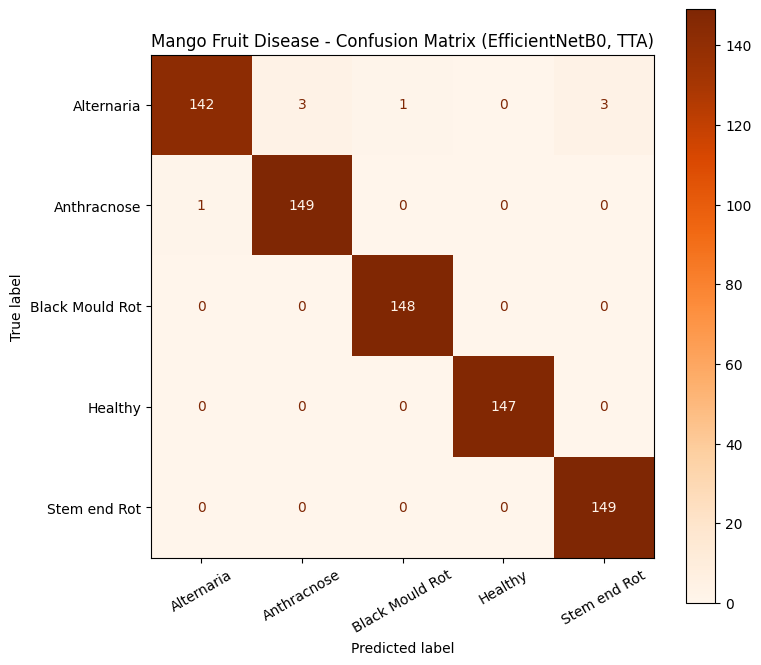

In [ ]:



cm = confusion_matrix(y_true, y_pred_tta)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, xticks_rotation=30, cmap="Oranges", colorbar=True)
plt.title("Mango Fruit Disease - Confusion Matrix (EfficientNetB0, TTA)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix_tta.png"))
plt.show()


In [ ]:
model.save(os.path.join(OUT_DIR, "mango_fruit_efficientnetb0_final.keras"))
with open(os.path.join(OUT_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f, indent=2)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(os.path.join(OUT_DIR, "mango_fruit_efficientnetb0.tflite"), "wb") as f:
    f.write(tflite_model)

print(f"\nDone. Artifacts saved to: {OUT_DIR}/")
print(f"FINAL RESULTS -> plain acc: {test_acc:.4f} | TTA acc: {tta_acc:.4f}")

INFO:tensorflow:Assets written to: C:\Users\udnrm\AppData\Local\Temp\tmpwjqd1ztp\assets


INFO:tensorflow:Assets written to: C:\Users\udnrm\AppData\Local\Temp\tmpwjqd1ztp\assets


Saved artifact at 'C:\Users\udnrm\AppData\Local\Temp\tmpwjqd1ztp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_244')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  1740123589904: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1740123589712: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  1740071390864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740071391248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740071391056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740071392016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740071391440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740071392400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740071392592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1740071391632: TensorSpec(shape=(), dtype=tf.resour